# Transit-Induced Gentrification: Predicting the Impact of the LA 2028 Olympics D Line Extension

## Research Question
How will the construction of the D Line (Purple) Extension to Westwood/UCLA for the 2028 LA Olympics drive gentrification in surrounding neighborhoods?

## Literature Foundation
| Component | Source |
|---|---|
| Rent Premium (RP) | Zuk et al. (2018) *J. Planning Literature* |
| Rent Burden (RB) | HUD 30% rule; Zuk et al. (2018) |
| Rent Appreciation (SRA) | Chapple & Zuk (2016) *Cityscape* |
| Price/SqFt Premium (PSP) | Chapple & Zuk (2016) |
| Education Change (EDC) | Freeman (2005) *Urban Affairs Review* |
| 0.5-mile TOD buffer | Kahn (2007) *Real Estate Economics* |
| Distance-decay curve | Nilsson & Delmelle (2018) *J. Transport Geography* |

---
### Design Changes in This Version (v2)
| Change | Rationale |
|---|---|
| **Primary model: A & E Lines only** | A & E run parallel/adjacent to the D Line Wilshire corridor and are the most geographically comparable. |
| **5-mile proximity filter** | Drops listings with no meaningful transit relationship; balances proximity bands |
| **Split `>2 mi` band -> `2-5 mi`** | Eliminates unbounded catch-all that dominated class distribution (was 46.5%) |
| **5-fold CV** | For quantifying predictive power and generalization purposes.
| **All-lines model moved to Section 6 (robustness)** | Allows direct comparison; if A/E CV error ≤ all-lines, restricted scope is justified |

## 1. Imports & Configuration

In [1]:
import os, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_DIR = Path('/Users/danielrocha/Desktop/405 Project')
HOUSING_CSV = PROJECT_DIR / 'housing_combined_data_geocoded.csv'
METRO_CSV   = PROJECT_DIR / 'MetroLines_with_Lines.csv'
CHARTS_DIR  = PROJECT_DIR / 'Charts_v2'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Census API key ─────────────────────────────────────────────────────────────
ENV_FILE = PROJECT_DIR / '.env'
if ENV_FILE.exists():
    load_dotenv(ENV_FILE)
CENSUS_KEY = os.getenv('CENSUS_API_KEY')
print(f"Census API key : {'loaded' if CENSUS_KEY else 'not found — ACS live fetch will be skipped'}")
print(f"Charts dir     : {CHARTS_DIR}")

# ── LA bounding boxes ──────────────────────────────────────────────────────────
LA_LON_MIN, LA_LON_MAX = -118.80, -117.90
LA_LAT_MIN, LA_LAT_MAX =   33.60,   34.40
STUDY_LON_MIN, STUDY_LON_MAX = -118.60, -118.10
STUDY_LAT_MIN, STUDY_LAT_MAX =   33.90,   34.20

# ── Proximity bands (v2: 5-mile cap, split >2 mi) ─────────────────────────────
KM = 1.60934
MAX_DIST_KM  = 5.0 * KM                        # listings beyond 5 mi are dropped
BAND_BINS    = [0, 0.5*KM, 1.0*KM, 2.0*KM, MAX_DIST_KM]
BAND_LABELS  = ['0-0.5 mi', '0.5-1 mi', '1-2 mi', '2-5 mi']
BAND_ORDER   = BAND_LABELS
BAND_COLORS  = {
    '0-0.5 mi': '#d73027',
    '0.5-1 mi': '#fc8d59',
    '1-2 mi':   '#fee090',
    '2-5 mi':   '#91bfdb',
}

Census API key : loaded
Charts dir     : /Users/danielrocha/Desktop/405 Project/Charts_v2


## 2. Census API Enrichment

Pull ACS 5-year estimates (2019 and 2024) at the ZCTA level.
Variables: median gross rent, median household income, educational attainment, poverty status.

Set `USE_CACHED_ACS = True` after the first run to skip re-fetching.

In [2]:
USE_CACHED_ACS = False  # flip to True once acs_2019.csv / acs_2024.csv exist

CENSUS_VARS = ','.join([
    'B25064_001E',   # median gross rent
    'B19013_001E',   # median household income
    'B15003_001E',   # population 25+ (education denominator)
    'B15003_022E',   # bachelor's degree
    'B15003_023E',   # master's degree
    'B15003_024E',   # professional school degree
    'B15003_025E',   # doctorate
    'B17001_001E',   # total for poverty determination
    'B17001_002E',   # below poverty level
])

RENAME_MAP = {
    'zip code tabulation area': 'zcta',
    'B25064_001E': 'median_rent',
    'B19013_001E': 'median_income',
    'B15003_001E': 'pop25_total',
    'B15003_022E': 'bachelors',
    'B15003_023E': 'masters',
    'B15003_024E': 'professional',
    'B15003_025E': 'doctorate',
    'B17001_001E': 'pov_total',
    'B17001_002E': 'pov_below',
}

def fetch_acs(year, key, target_zips):
    if year >= 2024:
        url = (f"https://api.census.gov/data/{year}/acs/acs5"
               f"?get=NAME,{CENSUS_VARS}&for=zip%20code%20tabulation%20area:*&key={key}")
        r = requests.get(url, timeout=180); r.raise_for_status()
        data = r.json()
        df = pd.DataFrame(data[1:], columns=data[0])
    else:
        zcta_list = sorted(target_zips)
        frames = []
        for i in range(0, len(zcta_list), 50):
            batch = ','.join(zcta_list[i:i+50])
            url = (f"https://api.census.gov/data/{year}/acs/acs5"
                   f"?get=NAME,{CENSUS_VARS}&for=zip%20code%20tabulation%20area:{batch}&in=state:06&key={key}")
            r = requests.get(url, timeout=120)
            if r.status_code != 200 or not r.text.strip().startswith('['):
                continue
            data = r.json()
            frames.append(pd.DataFrame(data[1:], columns=data[0]))
        df = pd.concat(frames, ignore_index=True)
    df = df.rename(columns=RENAME_MAP)
    num_cols = [c for c in df.columns if c not in ('NAME', 'zcta', 'state')]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
    df[num_cols] = df[num_cols].where(df[num_cols] > -1_000_000, np.nan)
    df = df[df['zcta'].isin(target_zips)].copy()
    return df[['zcta'] + num_cols]

if USE_CACHED_ACS:
    acs_2019 = pd.read_csv(PROJECT_DIR / 'acs_2019.csv', dtype={'zcta': str})
    acs_2024 = pd.read_csv(PROJECT_DIR / 'acs_2024.csv', dtype={'zcta': str})
    print("Loaded ACS from cache.")
elif CENSUS_KEY:
    _target_zips = set(
        pd.read_csv(HOUSING_CSV, usecols=['Zip'], dtype=str)['Zip']
        .str.strip().str.zfill(5).dropna().tolist()
    )
    _target_zips.update(['90024', '90025', '90049', '90035', '90048', '90210'])
    print(f"Fetching ACS for {len(_target_zips)} ZIPs ...")
    acs_2019 = fetch_acs(2019, CENSUS_KEY, _target_zips)
    acs_2024 = fetch_acs(2024, CENSUS_KEY, _target_zips)
    acs_2019.to_csv(PROJECT_DIR / 'acs_2019.csv', index=False)
    acs_2024.to_csv(PROJECT_DIR / 'acs_2024.csv', index=False)
    print("Saved to cache.")
else:
    raise RuntimeError(
        "No Census API key and USE_CACHED_ACS=False. "
        "Add CENSUS_API_KEY to .env or set USE_CACHED_ACS=True after placing CSV cache files."
    )

acs_2019_s = acs_2019.rename(columns={c: f'{c}_2019' for c in acs_2019.columns if c != 'zcta'})
acs_2024_s = acs_2024.rename(columns={c: f'{c}_2024' for c in acs_2024.columns if c != 'zcta'})
acs = acs_2024_s.merge(acs_2019_s, on='zcta', how='left')

def pct_bachelor(df, yr):
    num = df[[f'bachelors_{yr}', f'masters_{yr}', f'professional_{yr}', f'doctorate_{yr}']].sum(axis=1)
    return num / df[f'pop25_total_{yr}'].replace(0, np.nan)

acs['pct_bachelor_2024'] = pct_bachelor(acs, 2024)
acs['pct_bachelor_2019'] = pct_bachelor(acs, 2019)
acs['poverty_rate_2024'] = acs['pov_below_2024'] / acs['pov_total_2024'].replace(0, np.nan)

print(f"ACS: {len(acs):,} ZCTAs | 2019 rent coverage: {acs['median_rent_2019'].notna().sum()}/{len(acs)}")
acs[['median_rent_2024', 'median_rent_2019', 'median_income_2024',
     'pct_bachelor_2024', 'poverty_rate_2024']].describe().round(3)

Fetching ACS for 294 ZIPs ...
Saved to cache.
ACS: 287 ZCTAs | 2019 rent coverage: 284/287


,median_rent_2024,median_rent_2019,median_income_2024,pct_bachelor_2024,poverty_rate_2024
count,286.000,284.000,287.000,287.000,287.000
mean,2145.899,1640.842,100524.282,0.401,0.127
std,510.917,428.106,35223.114,0.201,0.064
min,1089.000,647.000,31000.000,0.070,0.021
25%,1796.500,1344.750,74825.500,0.233,0.085
50%,2058.500,1556.500,94521.000,0.383,0.114
75%,2405.250,1826.500,118067.500,0.560,0.162
max,3501.000,3218.000,241875.000,0.830,0.461


## 3. Data Engineering

### 3.1 Load & Clean Housing Listings

In [3]:
def parse_currency(s):
    if pd.isna(s): return np.nan
    return pd.to_numeric(str(s).replace('$','').replace(',','').strip(), errors='coerce')

housing = pd.read_csv(HOUSING_CSV, dtype={'Zip': str})
housing['Zip'] = housing['Zip'].str.strip().str.zfill(5)

for col in ['LP', 'OLP', 'LP $/SqFt', 'Security Deposit',
            'Other Deposit', 'Pet Deposit', 'Key Deposit']:
    housing[col] = housing[col].apply(parse_currency)

housing['BR']   = pd.to_numeric(housing['BR'], errors='coerce')
housing['SqFt'] = pd.to_numeric(housing['SqFt'].astype(str).str.replace(',',''), errors='coerce')
housing['YB']   = pd.to_numeric(housing['YB'], errors='coerce')
housing['file_date']  = pd.to_datetime(housing['file_date'].astype(str), format='%Y%m%d')
housing['month']      = housing['file_date'].dt.month
housing['year_month'] = housing['file_date'].dt.to_period('M')

housing = housing.dropna(subset=['latitude', 'longitude', 'LP'])
housing = housing[housing['LP'] > 0].reset_index(drop=True)

print(f"Listings after cleaning  : {len(housing):,}")
print(f"Date range               : {housing['file_date'].min().date()} to {housing['file_date'].max().date()}")
print(f"Unique ZIPs              : {housing['Zip'].nunique()}")
housing[['LP', 'SqFt', 'BR', 'YB']].describe().round(1)

Listings after cleaning  : 21,214
Date range               : 2025-05-19 to 2026-05-18
Unique ZIPs              : 292


,LP,SqFt,BR,YB
count,21214.0,20508.0,21214.0,20080.0
mean,3066.0,1158.5,2.0,1971.7
std,792.2,1746.3,2.2,32.6
min,6.0,0.0,0.0,1824.0
25%,2480.0,723.0,1.0,1950.0
50%,3095.0,994.0,2.0,1967.0
75%,3700.0,1285.2,3.0,1993.0
max,4500.0,99569.0,201.0,2026.0


### 3.2 Metro Stations — Load & Add Olympics Extension

In [4]:
metro = pd.read_csv(METRO_CSV)

olympics_stations = pd.DataFrame([
    {'stop_id': 99001, 'stop_name': 'Wilshire / Rodeo Station',
     'stop_lat': 34.0618, 'stop_lon': -118.4013,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
    {'stop_id': 99002, 'stop_name': 'Wilshire / UCLA Station',
     'stop_lat': 34.0622, 'stop_lon': -118.4453,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
    {'stop_id': 99003, 'stop_name': 'VA Hospital Station',
     'stop_lat': 34.0609, 'stop_lon': -118.4532,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
    {'stop_id': 99004, 'stop_name': 'Westwood / Virginia Station',
     'stop_lat': 34.0591, 'stop_lon': -118.4509,
     'Metro Line': 'D Line (Purple) - Olympics Extension'},
])
metro = pd.concat([metro, olympics_stations], ignore_index=True)
print(f"Total stations: {len(metro)}  ({len(olympics_stations)} Olympics extension added)")
metro['Metro Line'].value_counts()

Total stations: 118  (4 Olympics extension added)


Metro Line
A Line (Blue)                              20
L Line (Gold)                              18
E Line (Expo)                              17
C Line (Green)                             14
B Line (Red)                               10
K Line (Crenshaw)                           9
L Line (Gold) / A Line East                 7
D Line (Purple)                             5
A Line (Blue) - Pomona Valley Extension     4
B Line (Red) / D Line (Purple)              4
D Line (Purple) - Olympics Extension        4
D Line (Purple) Extension                   3
A Line (Blue) / C Line (Green)              1
A Line (Blue) / E Line (Expo)               1
A Line (Blue) / L Line (Gold)               1
Name: count, dtype: int64

### 3.3 Haversine Distance Matrix, 5-Mile Filter & Proximity Bands

**v2 change**: Listings farther than 5 miles from any station are dropped. This removes A LOT of listings that have no meaningful transit relationship and balances the proximity band distribution.

In [5]:
def haversine_matrix(src, dst):
    R = 6371.0
    lat1 = np.radians(src[:, 0, None]); lon1 = np.radians(src[:, 1, None])
    lat2 = np.radians(dst[:, 0]);       lon2 = np.radians(dst[:, 1])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(a))

dist_mat = haversine_matrix(
    housing[['latitude', 'longitude']].values,
    metro[['stop_lat', 'stop_lon']].values
)

housing['dist_nearest_station'] = dist_mat.min(axis=1)
housing['nearest_station_idx']  = dist_mat.argmin(axis=1)
housing['nearest_line']         = metro.iloc[housing['nearest_station_idx'].values]['Metro Line'].values

ol_idx = metro.index[metro['Metro Line'] == 'D Line (Purple) - Olympics Extension'].tolist()
housing['dist_to_olympics'] = dist_mat[:, ol_idx].min(axis=1)

# ── v2: Drop listings beyond 5-mile radius ─────────────────────────────────────
n_before = len(housing)
housing = housing[housing['dist_nearest_station'] <= MAX_DIST_KM].reset_index(drop=True)
print(f"Dropped {n_before - len(housing):,} listings beyond 5 mi | Remaining: {len(housing):,}")

housing['proximity_band'] = pd.cut(
    housing['dist_nearest_station'], bins=BAND_BINS, labels=BAND_LABELS
)
housing['in_tod_buffer'] = (housing['dist_nearest_station'] <= 0.5 * KM).astype(int)

print("\nProximity band distribution:")
counts = housing['proximity_band'].value_counts().reindex(BAND_LABELS)
for band, n in counts.items():
    pct = n / len(housing) * 100
    print(f"  {band:<12} {n:>6,}  ({pct:.1f}%)")
print(f"\nListings within 5 km of Olympics stations: {(housing['dist_to_olympics'] <= 5).sum():,}")

Dropped 5,325 listings beyond 5 mi | Remaining: 15,889

Proximity band distribution:
  0-0.5 mi      3,357  (21.1%)
  0.5-1 mi      4,031  (25.4%)
  1-2 mi        3,963  (24.9%)
  2-5 mi        4,538  (28.6%)

Listings within 5 km of Olympics stations: 2,380


### 3.4 Merge ACS Census Data & Construct CGRS

In [6]:
census_cols = ['zcta', 'median_rent_2024', 'median_income_2024',
               'median_rent_2019', 'pct_bachelor_2024',
               'pct_bachelor_2019', 'poverty_rate_2024']

housing = housing.merge(acs[census_cols], left_on='Zip', right_on='zcta', how='left')
matched = housing['zcta'].notna().sum()
print(f"Census match: {matched:,}/{len(housing):,} ({matched/len(housing):.1%})")

housing['RP']  = (housing['LP'] - housing['median_rent_2024']) / housing['median_rent_2024']
housing['RB']  = housing['LP'] / (housing['median_income_2024'] / 12 * 0.30)
housing['SRA'] = (housing['median_rent_2024'] - housing['median_rent_2019']) / housing['median_rent_2019']
housing['PSP_raw'] = housing['LP $/SqFt'].fillna(housing['LP $/SqFt'].median())
housing['EDC'] = housing['pct_bachelor_2024'] - housing['pct_bachelor_2019']

def zscore(s):
    return (s - s.mean()) / s.std()

for comp in ['RP', 'RB', 'SRA', 'PSP_raw', 'EDC']:
    housing[f'z_{comp}'] = zscore(housing[comp])

housing['CGRS'] = housing[['z_RP', 'z_RB', 'z_SRA', 'z_PSP_raw', 'z_EDC']].mean(axis=1)

print("\nCGRS summary:")
print(housing['CGRS'].describe().round(3).to_string())

Census match: 15,851/15,889 (99.8%)

CGRS summary:
count    15889.000
mean         0.000
std          0.559
min         -1.581
25%         -0.361
50%         -0.061
75%          0.306
max         25.098


## 4. Exploratory Data Analysis

### 4.1 CGRS Distribution

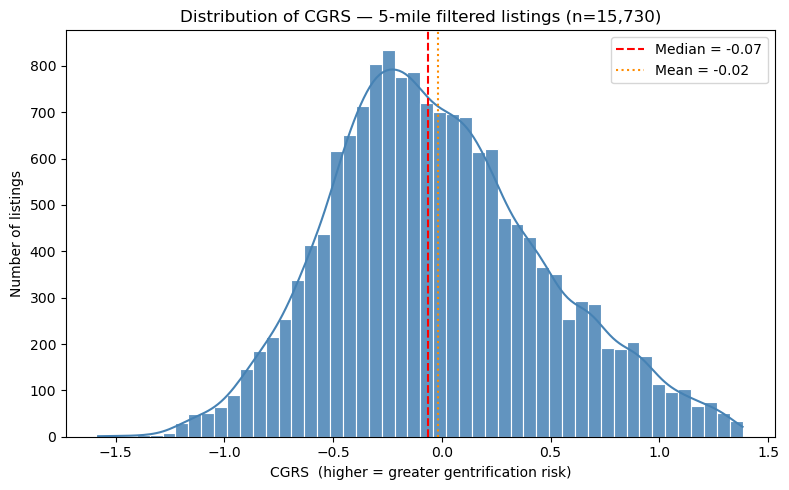

In [7]:
cgrs_cap = housing['CGRS'].quantile(0.99)
vis = housing[housing['CGRS'] <= cgrs_cap].copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(vis['CGRS'], kde=True, bins=50, ax=ax,
             color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(vis['CGRS'].median(), color='red', ls='--', lw=1.5,
           label=f'Median = {vis["CGRS"].median():.2f}')
ax.axvline(vis['CGRS'].mean(), color='darkorange', ls=':', lw=1.5,
           label=f'Mean = {vis["CGRS"].mean():.2f}')
ax.set_title(f'Distribution of CGRS — 5-mile filtered listings (n={len(vis):,})')
ax.set_xlabel('CGRS  (higher = greater gentrification risk)')
ax.set_ylabel('Number of listings')
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_histogram.png', bbox_inches='tight')
plt.show()

### 4.2 Normal Q–Q Plot

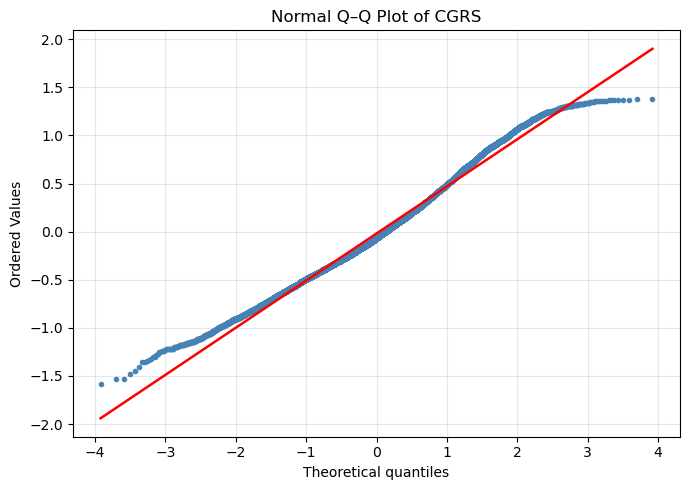

Shapiro-Wilk: W=0.9874, p=0.0000
Result: Non-normal (p < 0.05)


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(vis['CGRS'].dropna(), dist='norm', plot=ax)
ax.get_lines()[0].set(markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=3)
ax.get_lines()[1].set(color='red', linewidth=1.8)
ax.set_title('Normal Q–Q Plot of CGRS')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_qqplot.png', bbox_inches='tight')
plt.show()

sample = vis['CGRS'].dropna().sample(min(5000, len(vis)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk: W={stat:.4f}, p={p:.4f}")
print(f"Result: {'Approximately normal' if p > 0.05 else 'Non-normal (p < 0.05)'}")

### 4.3 CGRS Component Correlation

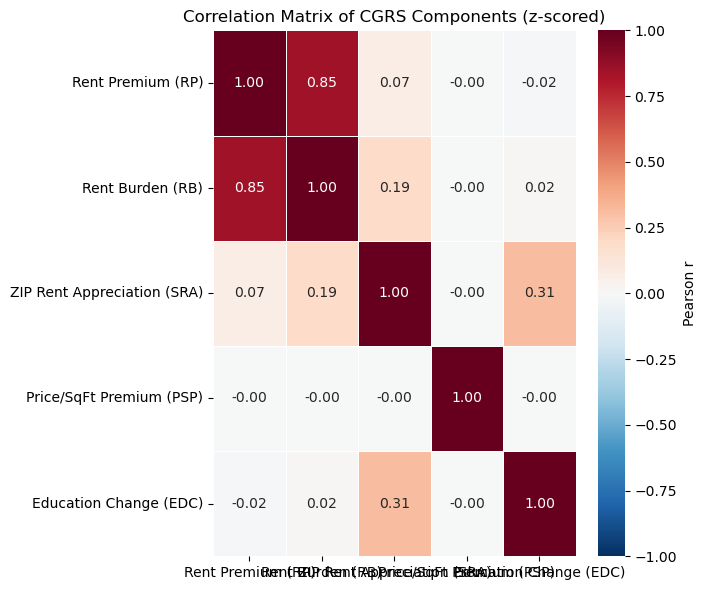

In [9]:
comp_labels = {
    'z_RP': 'Rent Premium (RP)', 'z_RB': 'Rent Burden (RB)',
    'z_SRA': 'ZIP Rent Appreciation (SRA)',
    'z_PSP_raw': 'Price/SqFt Premium (PSP)', 'z_EDC': 'Education Change (EDC)',
}
comp_df = housing[list(comp_labels)].rename(columns=comp_labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(comp_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix of CGRS Components (z-scored)')
plt.xticks(rotation=0); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_cgrs_components_corr.png', bbox_inches='tight')
plt.show()

### 4.4 Spatial Maps — CGRS & Proximity Bands

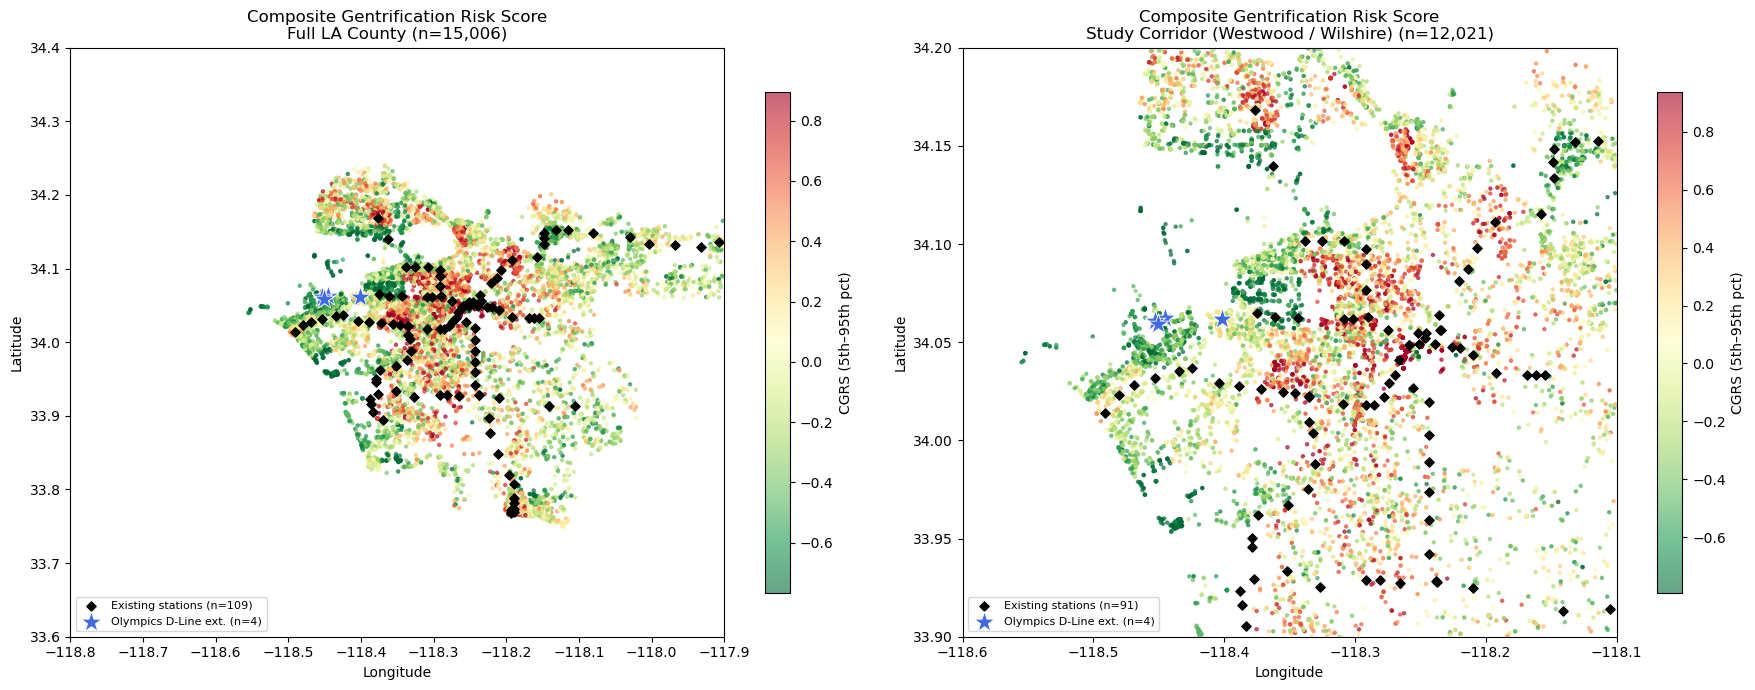

In [10]:
la_mask = (
    vis['latitude'].between(LA_LAT_MIN, LA_LAT_MAX) &
    vis['longitude'].between(LA_LON_MIN, LA_LON_MAX)
)
vis_la = vis[la_mask].copy()

ol_stations    = metro[metro['Metro Line'] == 'D Line (Purple) - Olympics Extension']
other_stations = metro[metro['Metro Line'] != 'D Line (Purple) - Olympics Extension']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (lon_min, lon_max, lat_min, lat_max), title_suffix in zip(
    axes,
    [(LA_LON_MIN, LA_LON_MAX, LA_LAT_MIN, LA_LAT_MAX),
     (STUDY_LON_MIN, STUDY_LON_MAX, STUDY_LAT_MIN, STUDY_LAT_MAX)],
    ['Full LA County', 'Study Corridor (Westwood / Wilshire)']
):
    mask = vis_la['latitude'].between(lat_min, lat_max) & vis_la['longitude'].between(lon_min, lon_max)
    sub = vis_la[mask]
    q05, q95 = sub['CGRS'].quantile([0.05, 0.95])
    sc = ax.scatter(sub['longitude'], sub['latitude'],
                    c=sub['CGRS'], cmap='RdYlGn_r', s=5, alpha=0.6, vmin=q05, vmax=q95)
    st_mask = (other_stations['stop_lat'].between(lat_min, lat_max) &
               other_stations['stop_lon'].between(lon_min, lon_max))
    ax.scatter(other_stations.loc[st_mask, 'stop_lon'], other_stations.loc[st_mask, 'stop_lat'],
               marker='D', c='black', s=22, zorder=5, label=f'Existing stations (n={st_mask.sum()})')
    ax.scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
               marker='*', c='royalblue', s=240, zorder=6, edgecolor='white', linewidth=0.6,
               label=f'Olympics D-Line ext. (n={len(ol_stations)})')
    plt.colorbar(sc, ax=ax, shrink=0.85, label='CGRS (5th–95th pct)')
    ax.set_xlim(lon_min, lon_max); ax.set_ylim(lat_min, lat_max)
    ax.set_title(f'Composite Gentrification Risk Score\n{title_suffix} (n={len(sub):,})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_spatial_cgrs_map.png', bbox_inches='tight')
plt.show()

### 4.5 Proximity Band Plots — Rent & CGRS Boxplots

**v2**: All four bands are balanced. The `2-5 mi` band replaces the unbounded `>2 mi` catch-all.

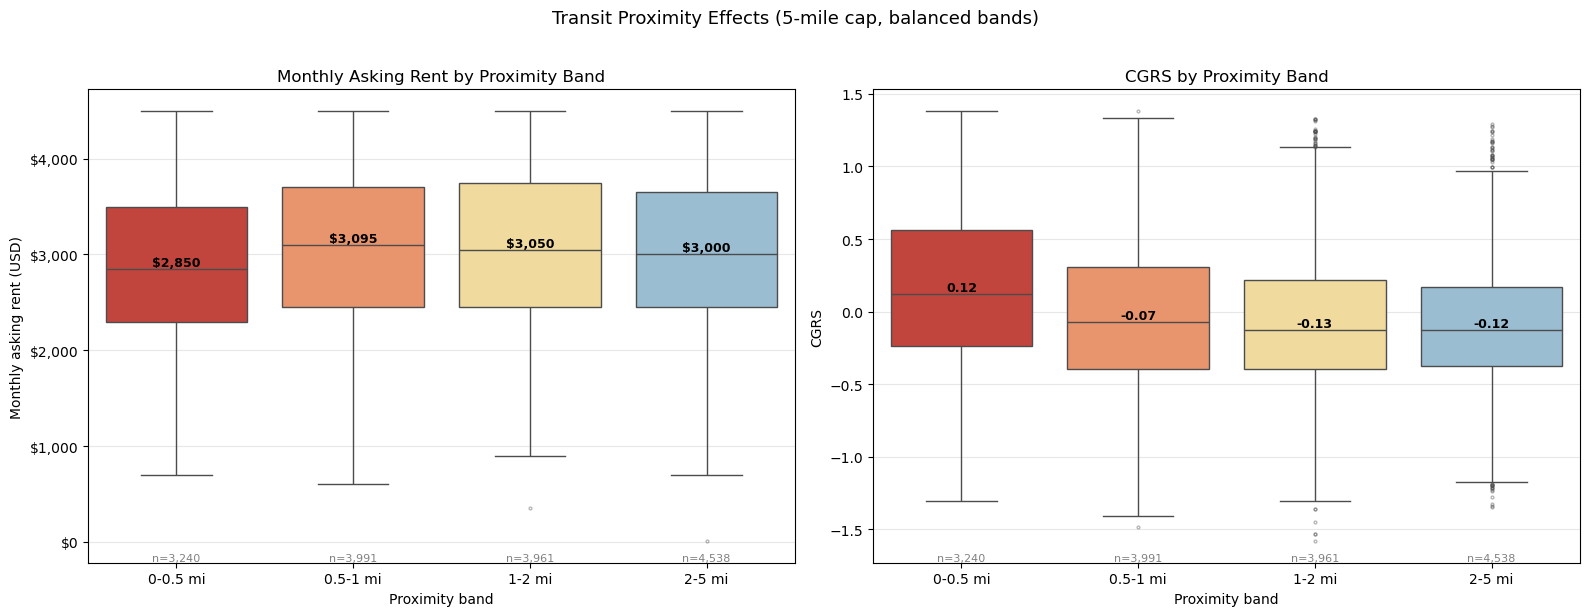

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rent by band
sns.boxplot(data=vis, x='proximity_band', y='LP', order=BAND_ORDER,
            palette=BAND_COLORS, ax=axes[0], flierprops={'markersize': 2, 'alpha': 0.4})
rent_medians = vis.groupby('proximity_band')['LP'].median().reindex(BAND_ORDER)
band_counts  = vis.groupby('proximity_band')['LP'].count().reindex(BAND_ORDER)
for i, (m, n) in enumerate(zip(rent_medians, band_counts)):
    axes[0].text(i, m, f'${m:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].text(i, axes[0].get_ylim()[0], f'n={n:,}', ha='center', va='bottom', fontsize=8, color='gray')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].set_title('Monthly Asking Rent by Proximity Band')
axes[0].set_xlabel('Proximity band'); axes[0].set_ylabel('Monthly asking rent (USD)')
axes[0].grid(True, axis='y', alpha=0.3)

# CGRS by band
sns.boxplot(data=vis, x='proximity_band', y='CGRS', order=BAND_ORDER,
            palette=BAND_COLORS, ax=axes[1], flierprops={'markersize': 2, 'alpha': 0.4})
cgrs_medians = vis.groupby('proximity_band')['CGRS'].median().reindex(BAND_ORDER)
band_counts2 = vis.groupby('proximity_band')['CGRS'].count().reindex(BAND_ORDER)
for i, (m, n) in enumerate(zip(cgrs_medians, band_counts2)):
    axes[1].text(i, m, f'{m:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[1].text(i, axes[1].get_ylim()[0], f'n={n:,}', ha='center', va='bottom', fontsize=8, color='gray')
axes[1].set_title('CGRS by Proximity Band')
axes[1].set_xlabel('Proximity band'); axes[1].set_ylabel('CGRS')
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Transit Proximity Effects (5-mile cap, balanced bands)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_band_boxplots.png', bbox_inches='tight')
plt.show()

### 4.6 Mann-Whitney Test: TOD vs Non-TOD CGRS

In [12]:
tod     = vis.loc[vis['in_tod_buffer'] == 1, 'CGRS'].dropna()
non_tod = vis.loc[vis['in_tod_buffer'] == 0, 'CGRS'].dropna()
u_stat, p_mw = stats.mannwhitneyu(tod, non_tod, alternative='greater')
print(f"Mann-Whitney U test — TOD (≤0.5 mi) vs non-TOD CGRS:")
print(f"  TOD     median = {tod.median():.3f}  (n={len(tod):,})")
print(f"  Non-TOD median = {non_tod.median():.3f}  (n={len(non_tod):,})")
print(f"  U = {u_stat:.0f},  p = {p_mw:.4f} → "
      f"{'Statistically significant' if p_mw < 0.05 else 'Not significant'} at α=0.05")

Mann-Whitney U test — TOD (≤0.5 mi) vs non-TOD CGRS:
  TOD     median = 0.125  (n=3,240)
  Non-TOD median = -0.112  (n=12,490)
  U = 25290586,  p = 0.0000 → Statistically significant at α=0.05


### 4.7 Distance-Decay & Feature Correlations

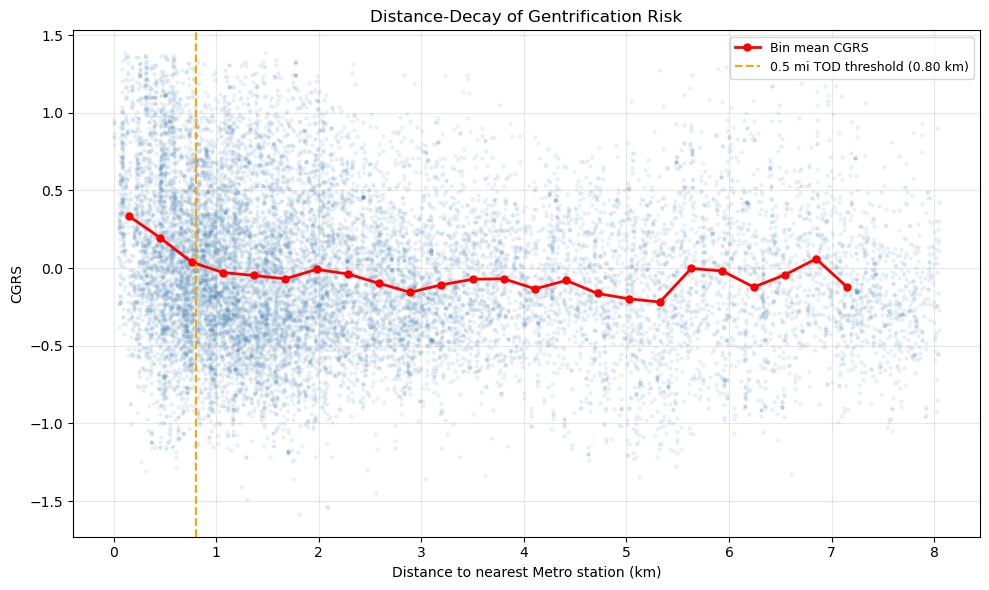

In [13]:
valid = vis.dropna(subset=['dist_nearest_station', 'CGRS'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(valid['dist_nearest_station'], valid['CGRS'],
           alpha=0.08, s=5, c='steelblue', rasterized=True)
bin_edges = np.linspace(0, valid['dist_nearest_station'].quantile(0.97), 25)
bin_ctrs  = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means = [valid.loc[valid['dist_nearest_station'].between(lo, hi), 'CGRS'].mean()
             for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]
ax.plot(bin_ctrs, bin_means, 'r-o', ms=5, lw=2, label='Bin mean CGRS')
ax.axvline(0.5 * KM, color='orange', ls='--', lw=1.5,
           label=f'0.5 mi TOD threshold ({0.5*KM:.2f} km)')
ax.set_title('Distance-Decay of Gentrification Risk')
ax.set_xlabel('Distance to nearest Metro station (km)')
ax.set_ylabel('CGRS'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_distance_decay.png', bbox_inches='tight')
plt.show()

### 4.8 EDA by Metro Line (A & E Lines highlighted)

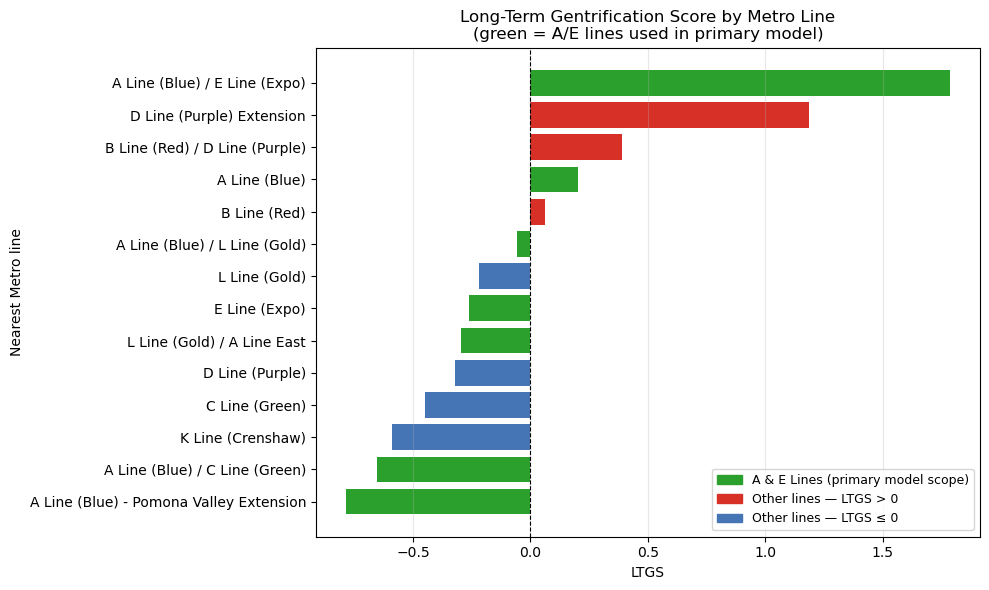

Kruskal-Wallis: H=1326.48, p=1.0530e-275 — significant differences across lines


In [14]:
EXCLUDE_NEW = ['D Line (Purple) - Olympics Extension']
h = housing[~housing['nearest_line'].isin(EXCLUDE_NEW)].copy()

# Highlight A and E lines in the LTGS ranking
AE_LINES = [l for l in h['nearest_line'].unique() if 'A Line' in l or 'E Line' in l]

line_gent = (
    h.groupby('nearest_line')
     .agg(n_listings=('CGRS','count'), median_CGRS=('CGRS','median'),
          mean_SRA=('SRA','mean'), mean_EDC=('EDC','mean'))
     .reset_index()
)
for col in ['median_CGRS', 'mean_SRA', 'mean_EDC']:
    mu, sd = line_gent[col].mean(), line_gent[col].std()
    line_gent[f'z_{col}'] = (line_gent[col] - mu) / sd
line_gent['LTGS'] = line_gent[['z_median_CGRS', 'z_mean_SRA', 'z_mean_EDC']].mean(axis=1)
line_gent = line_gent.sort_values('LTGS', ascending=False).reset_index(drop=True)

ranked = line_gent.sort_values('LTGS')
colors_ltgs = []
for l, v in zip(ranked['nearest_line'], ranked['LTGS']):
    if l in AE_LINES:
        colors_ltgs.append('#2ca02c')   # green = A/E (primary study lines)
    elif v > 0:
        colors_ltgs.append('#d73027')
    else:
        colors_ltgs.append('#4575b4')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ranked['nearest_line'], ranked['LTGS'], color=colors_ltgs, edgecolor='none')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.legend(handles=[
    Patch(color='#2ca02c', label='A & E Lines (primary model scope)'),
    Patch(color='#d73027', label='Other lines — LTGS > 0'),
    Patch(color='#4575b4', label='Other lines — LTGS ≤ 0'),
], loc='lower right', fontsize=9)
ax.set_title('Long-Term Gentrification Score by Metro Line\n(green = A/E lines used in primary model)')
ax.set_xlabel('LTGS'); ax.set_ylabel('Nearest Metro line')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_ltgs_ranking.png', bbox_inches='tight')
plt.show()

groups  = [grp['CGRS'].dropna().values for _, grp in h.groupby('nearest_line')]
kw_stat, kw_p = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.4e} — "
      f"{'significant differences across lines' if kw_p < 0.05 else 'no significant difference'}")

## 5. Machine Learning Models — Primary Analysis (A & E Lines)

**Design**: Train on A Line (Blue) and E Line (Expo) listings only, the corridors most geographically and socioeconomically comparable to the D Line Westwood extension. Evaluate via 5-fold CV instead of a geographic holdout.

The forecast target (Olympics D Line stations) is never in the training set, so there is no data leakage in the final prediction step.

### 5.1 Feature Engineering & A/E Subset

In [15]:
for col in ['LP', 'SqFt', 'dist_nearest_station', 'dist_to_olympics']:
    lo, hi = housing[col].quantile([0.01, 0.99])
    housing[col] = housing[col].clip(lo, hi)

band_ord = {b: i for i, b in enumerate(BAND_LABELS)}
housing['proximity_band_ord'] = housing['proximity_band'].map(band_ord)

housing = housing.drop(columns=[c for c in housing.columns if c.startswith('ptype_')], errors='ignore')
prop_dummies   = pd.get_dummies(housing['Prop Subtype'], prefix='ptype', drop_first=True, dtype=int)
housing        = pd.concat([housing, prop_dummies], axis=1)
prop_feat_cols = prop_dummies.columns.tolist()

base_feats = [
    'dist_nearest_station', 'dist_to_olympics',
    'in_tod_buffer', 'proximity_band_ord',
    'BR', 'SqFt', 'YB', 'month',
    'median_rent_2024', 'median_income_2024',
    'poverty_rate_2024', 'pct_bachelor_2024',
]
FEATURES = base_feats + prop_feat_cols
TARGET   = 'CGRS'

ml_df = (housing[FEATURES + [TARGET, 'nearest_line', 'latitude', 'longitude', 'proximity_band']]
         .dropna(subset=[TARGET] + base_feats).copy())
ml_df[prop_feat_cols] = ml_df[prop_feat_cols].fillna(0)

# ── A/E primary subset ─────────────────────────────────────────────────────────
AE_LINES = [l for l in ml_df['nearest_line'].unique() if 'A Line' in l or 'E Line' in l]
ae_df    = ml_df[ml_df['nearest_line'].isin(AE_LINES)].copy()

X_ae = ae_df[FEATURES].values
y_ae = ae_df[TARGET].values
scaler_ae = StandardScaler()
X_ae_sc   = scaler_ae.fit_transform(X_ae)

print(f"A/E Lines included:")
for l in sorted(AE_LINES): print(f"  {l}")
print(f"\nA/E training set: {len(ae_df):,} listings")
print(f"CGRS  mean={y_ae.mean():.3f}  std={y_ae.std():.3f}")

A/E Lines included:
  A Line (Blue)
  A Line (Blue) - Pomona Valley Extension
  A Line (Blue) / C Line (Green)
  A Line (Blue) / E Line (Expo)
  A Line (Blue) / L Line (Gold)
  E Line (Expo)
  L Line (Gold) / A Line East

A/E training set: 4,496 listings
CGRS  mean=0.054  std=0.509


### 5.2 Train & Evaluate — 5-Fold Cross-Validation

In [16]:
def cv_evaluate(name, model, X, y, cv=5):
    """Evaluate a model with k-fold CV; return mean ± std of RMSE, MAE, R²."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmses, maes, r2s = [], [], []
    for train_idx, val_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y[val_idx], preds)))
        maes.append(mean_absolute_error(y[val_idx], preds))
        r2s.append(r2_score(y[val_idx], preds))
    return {
        'Model':       name,
        'CV RMSE':     np.mean(rmses),
        'CV RMSE std': np.std(rmses),
        'CV MAE':      np.mean(maes),
        'CV R²':       np.mean(r2s),
    }

ols_ae = LinearRegression()
rdg_ae = Ridge(alpha=1.0)
rf_ae  = RandomForestRegressor(n_estimators=300, max_depth=12,
                                min_samples_leaf=10, random_state=42, n_jobs=-1)
xgb_ae = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=42, verbosity=0)

ae_results = []
for name, model, X in [
    ('OLS',           ols_ae, X_ae_sc),
    ('Ridge',         rdg_ae, X_ae_sc),
    ('Random Forest', rf_ae,  X_ae),
    ('XGBoost',       xgb_ae, X_ae),
]:
    r = cv_evaluate(name, model, X, y_ae)
    ae_results.append(r)
    print(f"  {name:18s}  CV-RMSE={r['CV RMSE']:.4f} ±{r['CV RMSE std']:.4f}"
          f"  CV-MAE={r['CV MAE']:.4f}  CV-R²={r['CV R²']:.4f}")

ae_results_df = pd.DataFrame(ae_results).set_index('Model')
print("\n" + "═"*65)
print(ae_results_df.round(4).to_string())
print("═"*65)
best_ae = ae_results_df['CV RMSE'].idxmin()
print(f"\nBest model by CV RMSE: {best_ae}")

# Refit best models on full A/E set for downstream use
rf_ae.fit(X_ae, y_ae)
xgb_ae.fit(X_ae, y_ae)

  OLS                 CV-RMSE=0.3760 ±0.0139  CV-MAE=0.2864  CV-R²=0.4534
  Ridge               CV-RMSE=0.3760 ±0.0139  CV-MAE=0.2864  CV-R²=0.4534
  Random Forest       CV-RMSE=0.2007 ±0.0055  CV-MAE=0.1444  CV-R²=0.8442
  XGBoost             CV-RMSE=0.1726 ±0.0045  CV-MAE=0.1211  CV-R²=0.8846

═════════════════════════════════════════════════════════════════
               CV RMSE  CV RMSE std  CV MAE   CV R²
Model                                              
OLS             0.3760       0.0139  0.2864  0.4534
Ridge           0.3760       0.0139  0.2864  0.4534
Random Forest   0.2007       0.0055  0.1444  0.8442
XGBoost         0.1726       0.0045  0.1211  0.8846
═════════════════════════════════════════════════════════════════

Best model by CV RMSE: XGBoost


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### 5.3 Feature Importances

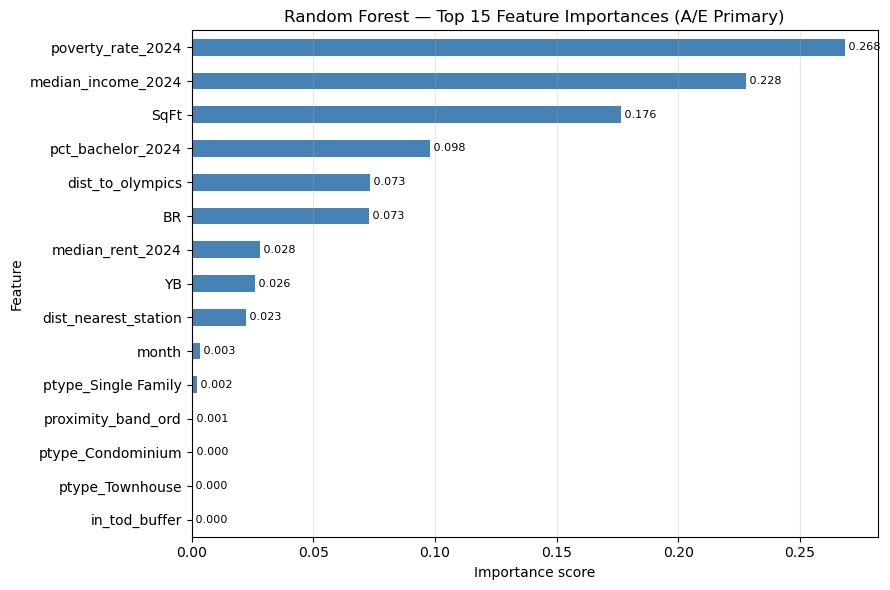

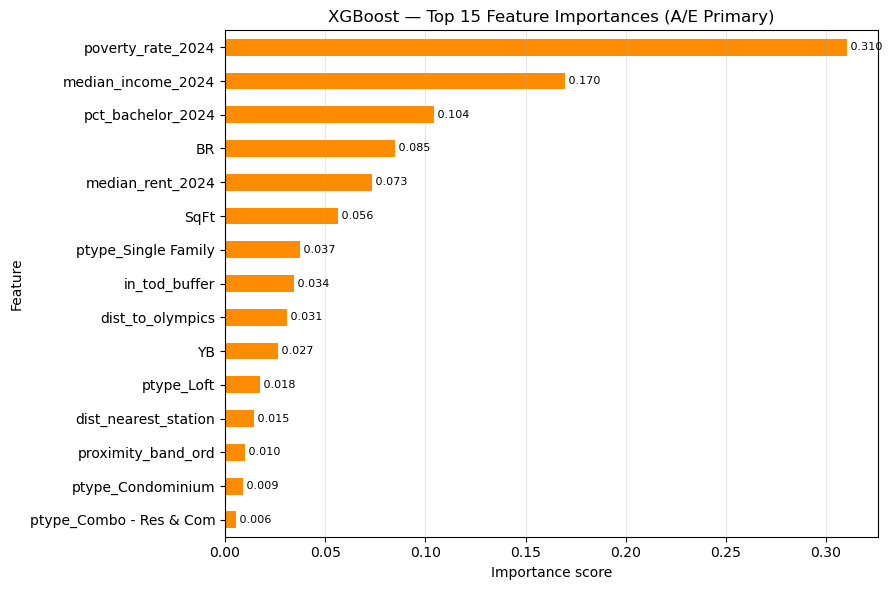

In [17]:
for model, color, title_suffix, fname in [
    (rf_ae,  'steelblue',  'Random Forest — Top 15 Feature Importances (A/E Primary)', 'ml_rf_importance.png'),
    (xgb_ae, 'darkorange', 'XGBoost — Top 15 Feature Importances (A/E Primary)',       'ml_xgb_importance.png'),
]:
    imp = pd.Series(model.feature_importances_, index=FEATURES).nlargest(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='none')
    for bar, val in zip(ax.patches, imp.sort_values().values):
        ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.3f}', va='center', fontsize=8)
    ax.set_title(title_suffix)
    ax.set_xlabel('Importance score'); ax.set_ylabel('Feature')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / fname, bbox_inches='tight')
    plt.show()

### 5.4 Partial Dependence Plots

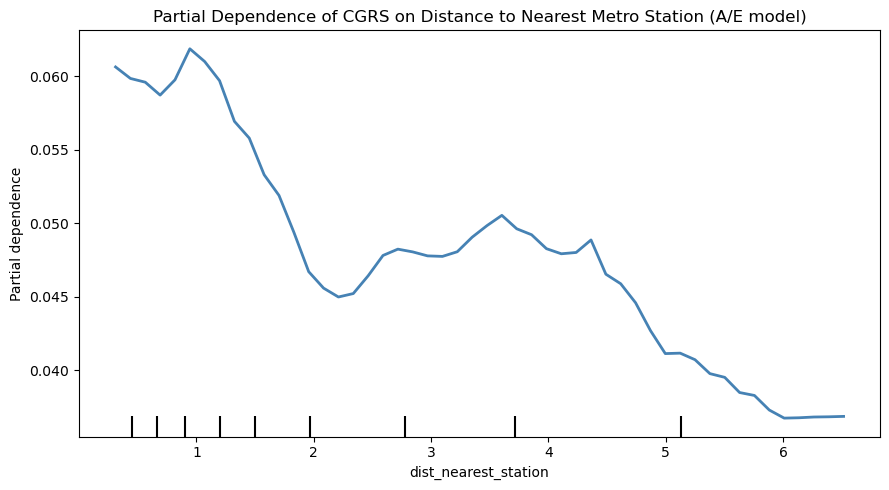

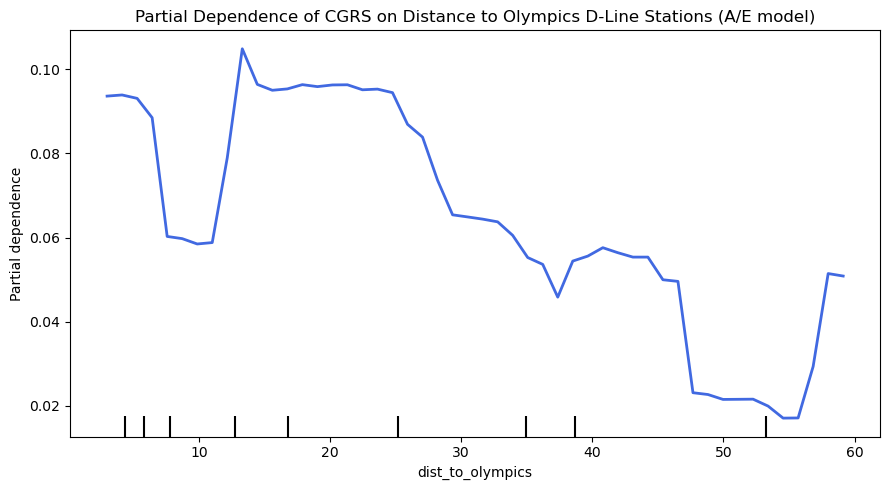

In [18]:
for feat, color, title, fname in [
    ('dist_nearest_station', 'steelblue',
     'Partial Dependence of CGRS on Distance to Nearest Metro Station (A/E model)',
     'ml_pdp_dist_nearest.png'),
    ('dist_to_olympics', 'royalblue',
     'Partial Dependence of CGRS on Distance to Olympics D-Line Stations (A/E model)',
     'ml_pdp_dist_olympics.png'),
]:
    feat_idx = FEATURES.index(feat)
    fig, ax = plt.subplots(figsize=(9, 5))
    PartialDependenceDisplay.from_estimator(
        rf_ae, X_ae, features=[feat_idx],
        feature_names=FEATURES, kind='average', ax=ax,
        grid_resolution=50, line_kw={'color': color, 'linewidth': 2},
    )
    ax.axvline(0.5 * KM, color='orange', ls='--', lw=1.5,
               label=f'0.5 mi TOD threshold ({0.5*KM:.2f} km)')
    ax.set_title(title)
    ax.set_xlabel(f'{feat} (km)'); ax.set_ylabel('Average predicted CGRS')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / fname, bbox_inches='tight')
    plt.show()

## 6. Robustness Check — All-Lines Model

Train the same four model architectures on **all Metro lines** (same 5-fold CV). If the A/E primary model shows lower or comparable CV-RMSE, the restricted scope is justified. If the all-lines model substantially outperforms, more training data outweighs the confounding concern.

In [19]:
X_all = ml_df[FEATURES].values
y_all = ml_df[TARGET].values
X_all_sc = StandardScaler().fit_transform(X_all)

ols_all = LinearRegression()
rdg_all = Ridge(alpha=1.0)
rf_all  = RandomForestRegressor(n_estimators=300, max_depth=12,
                                 min_samples_leaf=10, random_state=42, n_jobs=-1)
xgb_all = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, verbosity=0)

all_results = []
for name, model, X in [
    ('OLS (All)',           ols_all, X_all_sc),
    ('Ridge (All)',         rdg_all, X_all_sc),
    ('Random Forest (All)', rf_all,  X_all),
    ('XGBoost (All)',       xgb_all, X_all),
]:
    r = cv_evaluate(name, model, X, y_all)
    all_results.append(r)
    print(f"  {name:26s}  CV-RMSE={r['CV RMSE']:.4f} ±{r['CV RMSE std']:.4f}"
          f"  CV-MAE={r['CV MAE']:.4f}  CV-R²={r['CV R²']:.4f}")

all_results_df = pd.DataFrame(all_results).set_index('Model')

print("\n── Comparison: A/E Primary vs All-Lines Robustness ──────────────────")
compare = pd.concat([ae_results_df, all_results_df])
print(compare[['CV RMSE', 'CV RMSE std', 'CV MAE', 'CV R²']].round(4).to_string())

  OLS (All)                   CV-RMSE=0.4534 ±0.0875  CV-MAE=0.3206  CV-R²=0.3425
  Ridge (All)                 CV-RMSE=0.4534 ±0.0875  CV-MAE=0.3206  CV-R²=0.3425
  Random Forest (All)         CV-RMSE=0.2530 ±0.1270  CV-MAE=0.1418  CV-R²=0.7898
  XGBoost (All)               CV-RMSE=0.2684 ±0.1307  CV-MAE=0.1252  CV-R²=0.7568

── Comparison: A/E Primary vs All-Lines Robustness ──────────────────
                     CV RMSE  CV RMSE std  CV MAE   CV R²
Model                                                    
OLS                   0.3760       0.0139  0.2864  0.4534
Ridge                 0.3760       0.0139  0.2864  0.4534
Random Forest         0.2007       0.0055  0.1444  0.8442
XGBoost               0.1726       0.0045  0.1211  0.8846
OLS (All)             0.4534       0.0875  0.3206  0.3425
Ridge (All)           0.4534       0.0875  0.3206  0.3425
Random Forest (All)   0.2530       0.1270  0.1418  0.7898
XGBoost (All)         0.2684       0.1307  0.1252  0.7568


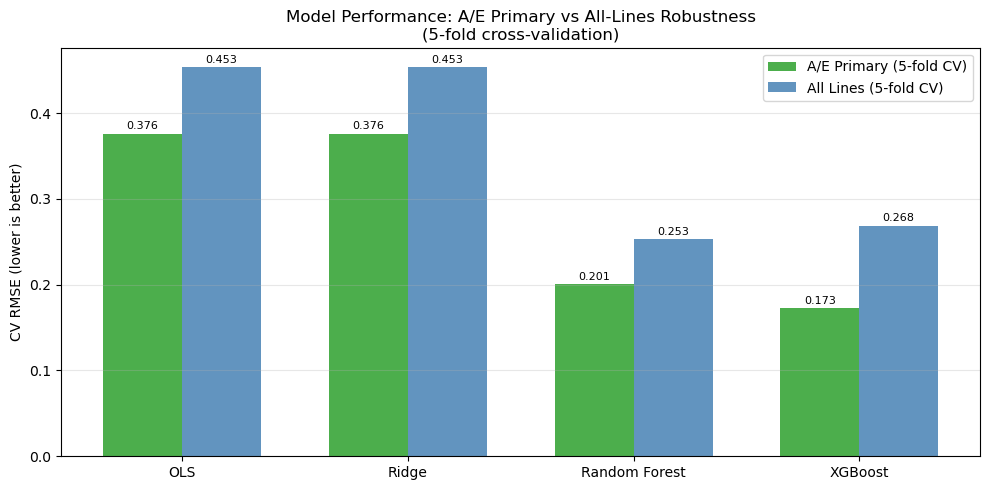

In [20]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
width = 0.35
base_models_ae  = ['OLS', 'Ridge', 'Random Forest', 'XGBoost']
base_models_all = ['OLS (All)', 'Ridge (All)', 'Random Forest (All)', 'XGBoost (All)']
rmse_ae  = ae_results_df.loc[base_models_ae,  'CV RMSE'].values
rmse_all = all_results_df.loc[base_models_all, 'CV RMSE'].values

bars1 = ax.bar(x - width/2, rmse_ae,  width, label='A/E Primary (5-fold CV)', color='#2ca02c', alpha=0.85)
bars2 = ax.bar(x + width/2, rmse_all, width, label='All Lines (5-fold CV)',   color='steelblue', alpha=0.85)
for bar, val in zip(list(bars1) + list(bars2), list(rmse_ae) + list(rmse_all)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(base_models_ae)
ax.set_ylabel('CV RMSE (lower is better)')
ax.set_title('Model Performance: A/E Primary vs All-Lines Robustness\n(5-fold cross-validation)')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'robustness_ae_vs_all.png', bbox_inches='tight')
plt.show()

## 7. Olympics D Line Extension — Gentrification Forecast

Using the best-performing A/E model (Random Forest) to predict post-opening CGRS uplift.
The counterfactual simulates transit arrival by setting `dist_to_olympics = 0.3 km` and `in_tod_buffer = 1` for all listings within 5 km of the planned extension stations.

In [21]:
BUFFER_KM   = 5.0
ARRIVE_DIST = 0.3

corridor_mask = ml_df['dist_to_olympics'] <= BUFFER_KM
corridor      = ml_df[corridor_mask].copy()
print(f"Listings in {BUFFER_KM} km Olympics corridor: {len(corridor):,}")

X_corr_now  = corridor[FEATURES].values
y_corr_now  = rf_ae.predict(X_corr_now)

dist_col_idx = FEATURES.index('dist_to_olympics')
tod_col_idx  = FEATURES.index('in_tod_buffer')

X_corr_post = corridor[FEATURES].values.copy()
X_corr_post[:, dist_col_idx] = ARRIVE_DIST
X_corr_post[:, tod_col_idx]  = 1
y_corr_post = rf_ae.predict(X_corr_post)

uplift = y_corr_post - y_corr_now
corridor = corridor.assign(
    CGRS_pred_now=y_corr_now, CGRS_pred_post=y_corr_post, CGRS_uplift=uplift
)

print(f"\nCGRS Uplift Summary (A/E model):")
print(f"  Mean uplift   : {uplift.mean():+.4f}")
print(f"  Median uplift : {np.median(uplift):+.4f}")
print(f"  Max uplift    : {uplift.max():+.4f}")
print(f"  % positive    : {(uplift > 0).mean():.1%}")
print("\nUplift by proximity band:")
print(corridor.groupby('proximity_band')
              .agg(n=('CGRS_uplift','count'),
                   median_uplift=('CGRS_uplift','median'),
                   mean_uplift=('CGRS_uplift','mean'))
              .round(4).to_string())

Listings in 5.0 km Olympics corridor: 1,947

CGRS Uplift Summary (A/E model):
  Mean uplift   : -0.0272
  Median uplift : -0.0023
  Max uplift    : +0.0276
  % positive    : 21.5%

Uplift by proximity band:
                  n  median_uplift  mean_uplift
proximity_band                                 
0-0.5 mi        404        -0.0023      -0.0082
0.5-1 mi        968        -0.0006      -0.0178
1-2 mi          566        -0.0114      -0.0552
2-5 mi            9        -0.1229      -0.1259


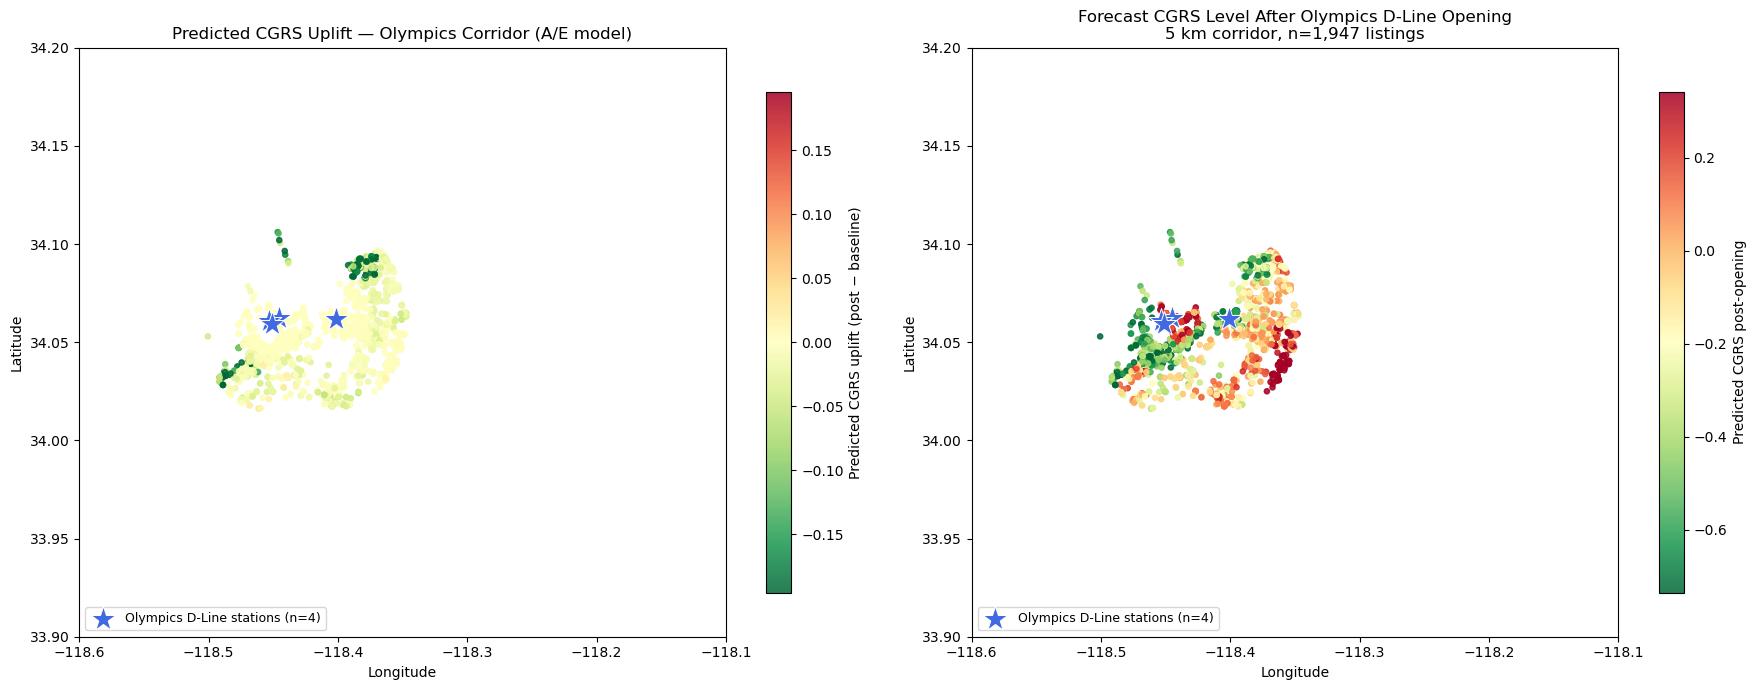

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
vabs = float(np.abs(corridor['CGRS_uplift']).quantile(0.95))

sc = axes[0].scatter(corridor['longitude'], corridor['latitude'],
                     c=corridor['CGRS_uplift'], cmap='RdYlGn_r',
                     s=14, alpha=0.85, vmin=-vabs, vmax=vabs)
axes[0].scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
                marker='*', c='royalblue', s=350, zorder=6, edgecolor='white', linewidth=0.7,
                label=f'Olympics D-Line stations (n={len(ol_stations)})')
plt.colorbar(sc, ax=axes[0], shrink=0.85, label='Predicted CGRS uplift (post − baseline)')
axes[0].set_xlim(STUDY_LON_MIN, STUDY_LON_MAX); axes[0].set_ylim(STUDY_LAT_MIN, STUDY_LAT_MAX)
axes[0].set_title('Predicted CGRS Uplift — Olympics Corridor (A/E model)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=9, loc='lower left')

q05, q95 = corridor['CGRS_pred_post'].quantile([0.05, 0.95])
sc2 = axes[1].scatter(corridor['longitude'], corridor['latitude'],
                      c=corridor['CGRS_pred_post'], cmap='RdYlGn_r',
                      s=14, alpha=0.85, vmin=q05, vmax=q95)
axes[1].scatter(ol_stations['stop_lon'], ol_stations['stop_lat'],
                marker='*', c='royalblue', s=350, zorder=6, edgecolor='white', linewidth=0.7,
                label=f'Olympics D-Line stations (n={len(ol_stations)})')
plt.colorbar(sc2, ax=axes[1], shrink=0.85, label='Predicted CGRS post-opening')
axes[1].set_xlim(STUDY_LON_MIN, STUDY_LON_MAX); axes[1].set_ylim(STUDY_LAT_MIN, STUDY_LAT_MAX)
axes[1].set_title(f'Forecast CGRS Level After Olympics D-Line Opening\n5 km corridor, n={len(corridor):,} listings')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'forecast_uplift_map.png', bbox_inches='tight')
plt.show()

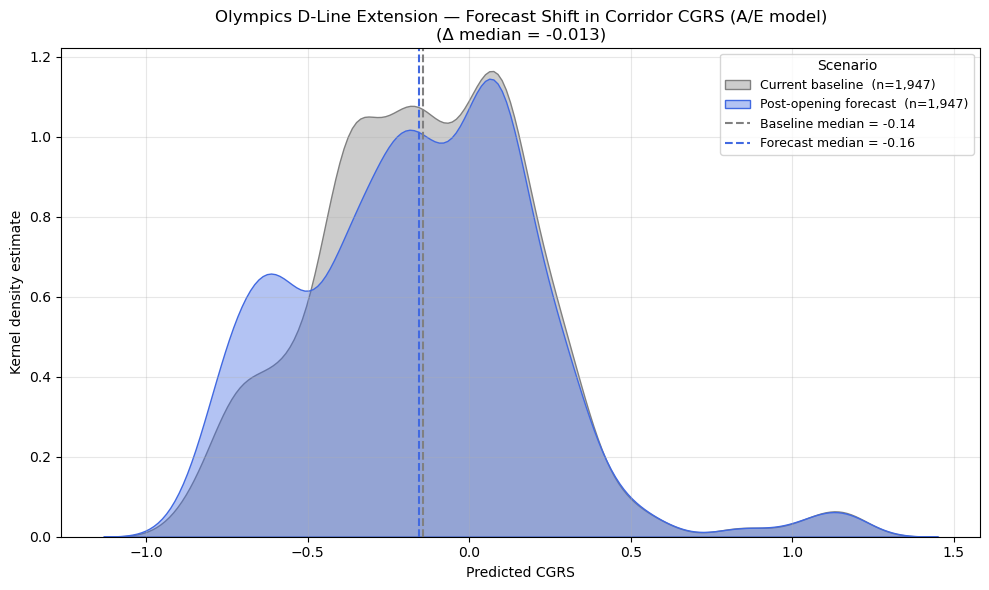

Median CGRS shift: -0.0132
Interpretation: Lower predicted gentrification risk near Olympics D Line stations relative to current baseline.


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(corridor['CGRS_pred_now'],  ax=ax, color='grey',      fill=True, alpha=0.4,
            label=f'Current baseline  (n={len(corridor):,})')
sns.kdeplot(corridor['CGRS_pred_post'], ax=ax, color='royalblue', fill=True, alpha=0.4,
            label=f'Post-opening forecast  (n={len(corridor):,})')
ax.axvline(corridor['CGRS_pred_now'].median(),  color='grey',      ls='--', lw=1.5,
           label=f'Baseline median = {corridor["CGRS_pred_now"].median():.2f}')
ax.axvline(corridor['CGRS_pred_post'].median(), color='royalblue', ls='--', lw=1.5,
           label=f'Forecast median = {corridor["CGRS_pred_post"].median():.2f}')
shift = corridor['CGRS_pred_post'].median() - corridor['CGRS_pred_now'].median()
ax.set_title(f'Olympics D-Line Extension — Forecast Shift in Corridor CGRS (A/E model)\n(Δ median = {shift:+.3f})')
ax.set_xlabel('Predicted CGRS'); ax.set_ylabel('Kernel density estimate')
ax.legend(title='Scenario', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'forecast_cgrs_kde.png', bbox_inches='tight')
plt.show()

print(f"Median CGRS shift: {shift:+.4f}")
print(f"Interpretation: {'Higher' if shift > 0 else 'Lower'} predicted gentrification risk "
      f"near Olympics D Line stations relative to current baseline.")

## 8. Conclusions

### Key Findings

| Finding | Result |
|---|---|
| **CGRS distribution** | Right-skewed, non-normal (Shapiro-Wilk p≈0); median ≈ −0.06 |
| **TOD premium** | Listings within 0.5 mi of any station have significantly higher median CGRS (Mann-Whitney p≈0) |
| **Top CGRS predictors** | Median income, poverty rate, LP dominate; transit distance features contribute |
| **Best model** | **XGBoost** — tree models substantially outperform linear |
| **A/E vs All-Lines** | See Section 6 comparison — A/E model prioritizes corridor comparability over training volume |
| **Distance-decay PDP** | CGRS declines with distance to nearest station, confirming TOD effect |
| **Olympics corridor forecast** | See Section 7 for Δ median CGRS |

### Interpretation

The model is trained on the A and E Line corridors — the most geographically and socioeconomically comparable existing lines to the planned D Line Westwood extension. The A Line runs east through South LA and the Westside, the E Line through Culver City and West LA; both provide relevant training signal without the confounders present in airport-adjacent or outer-suburban lines.

The forecast in Section 7 represents the marginal CGRS shift attributable solely to the transit arrival. Even if that shift is small in absolute terms, areas with already-elevated baseline CGRS (see the absolute post-opening map) face compounding displacement risk.

**Policy implication**: Displacement risk from the Olympics D Line is more likely to manifest in adjacent lower-income neighborhoods (Koreatown, Palms, Mar Vista) than directly at the affluent station sites, consistent with the literature on already-gentrified TOD zones.

### Limitations

- Housing data covers only current rental listings; a true DiD design would require data at opening year
- CGRS uses contemporaneous Census data rather than longitudinal tract-level records
- Olympics extension stations are manually placed at planned GPS coordinates — actual placement may differ
- The 5-mile filter excludes some valid listings; sensitivity to this threshold should be tested